In [55]:
##Exercise 4
##Task 1
A = np.ones((5, 5))
A[1:4, 1:4] = 0

##Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.min()) / (random_data.max() - random_data.min())
print(normalized)

##Task 3
#theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print(theta_hat)
print(true_theta)

[[0.52692164 0.4374124  0.54820363]
 [0.67159543 0.42389547 0.42389778]
 [0.67951522 0.56508355 0.39072363]
 [0.53338427 0.3915774  0.39125149]
 [0.49101074 0.18719866 0.21375102]
 [0.37764029 0.31412977 0.50120035]
 [0.32890381 0.25781843 0.66350675]
 [0.42507634 0.46642178 0.2560642 ]
 [0.38016423 0.47253883 0.29465381]
 [0.50986269 0.37223415 0.41578434]
 [0.37208361 0.71800766 0.45500009]
 [0.30780332 0.57285212 0.28480745]
 [0.48634501 0.18065935 0.26967601]
 [0.48465311 0.56100008 0.48105951]
 [0.44060045 0.41445787 0.24848402]
 [0.35543044 0.39196913 0.60591913]
 [0.5053406  0.20837714 0.50258696]
 [0.40261989 0.36148094 0.54312719]
 [0.60223676 0.58817989 0.33860307]
 [0.41331484 0.50359901 0.59441967]
 [0.3893563  0.43073144 0.30094907]
 [0.28828039 0.57143978 0.64808403]
 [0.44675187 0.59836495 0.50788046]
 [0.36596392 0.50784657 0.67371084]
 [0.45185253 0.67746149 0.0876124 ]
 [0.57276156 0.46917324 0.41475338]
 [0.4698377  0.17672662 0.42593684]
 [0.50724281 0.6652329  0.38

In [53]:
##Exercise 5
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math',
    'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


##Task 1
print(df.info())
print(df.isnull().sum())

df["exam_score"] = df["exam_score"].fillna(
    df.groupby("major")["exam_score"].transform("mean")
)

major_mean = df.groupby("major")["exam_score"].mean()
print(major_mean)


df["hours_studied"] = df["hours_studied"].fillna(
    df.groupby("year")["hours_studied"].transform("median")
)

##Task 2
firstOrdered = df.sort_values("exam_score", ascending = False)
df["exam_score"].mean()
print(firstOrdered)

correlation = df["hours_studied"].corr(df["exam_score"])
print(correlation)

df["status"] = "Active"

df["performance"] = "Student grading scheme"

df.loc[df["exam_score"] <70, "performance"] = "Needs improvement"
df.loc[df["exam_score"] >=70, "performance"] = "Average"
df.loc[df["exam_score"] >=80, "performance"] = "Good"
df.loc[df["exam_score"] >90, "performance"] = "Excellent"


##Task 3
print(df["student_id"].value_counts())
print(df["exam_score"].mean())
print(df["hours_studied"].mean())
SecondOrdered = df.sort_values("exam_score", ascending = False).head(5)
print(SecondOrdered)
pivot = pd.pivot_table(
    df, values = "exam_score", index = "major", columns = "year", aggfunc = "mean"
)
print(pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
     student_id    major  year  exam_score  assignments_completed  \
57         1057       CS     2  100.0000

Index(['student_id', 'major', 'year', 'exam_score', 'assignments_completed',
       'hours_studied', 'status', 'performance'],
      dtype='object')


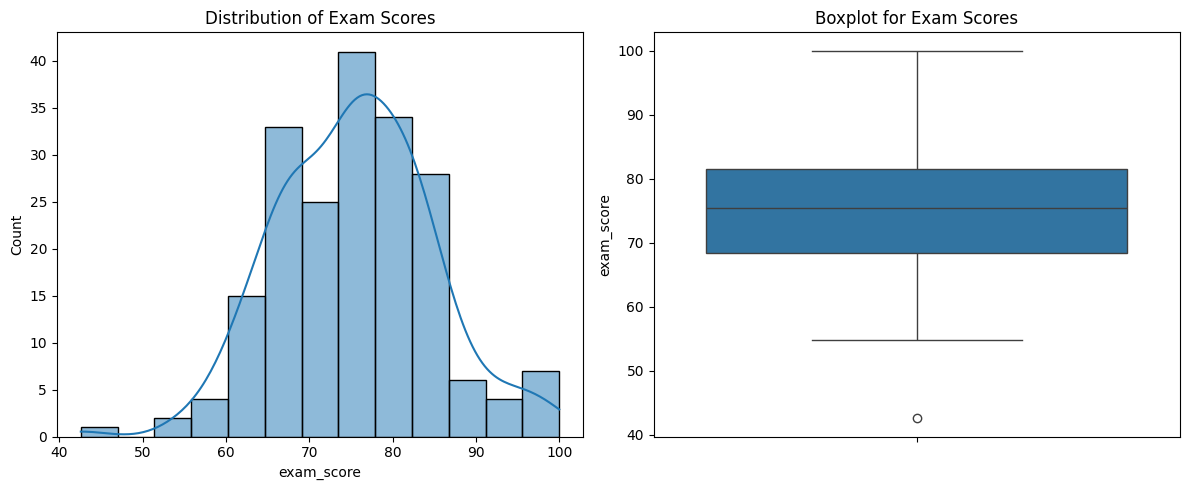

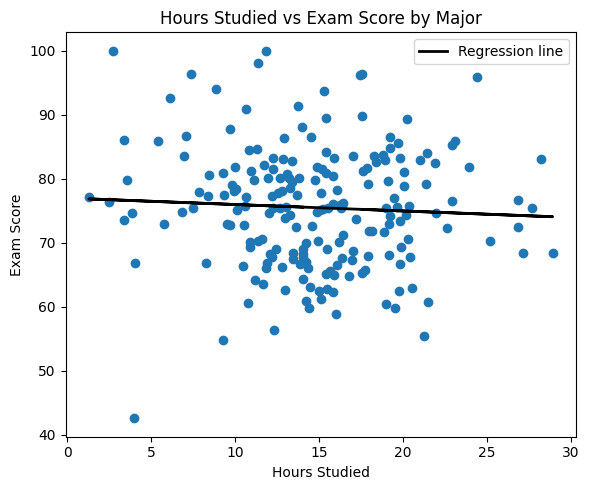

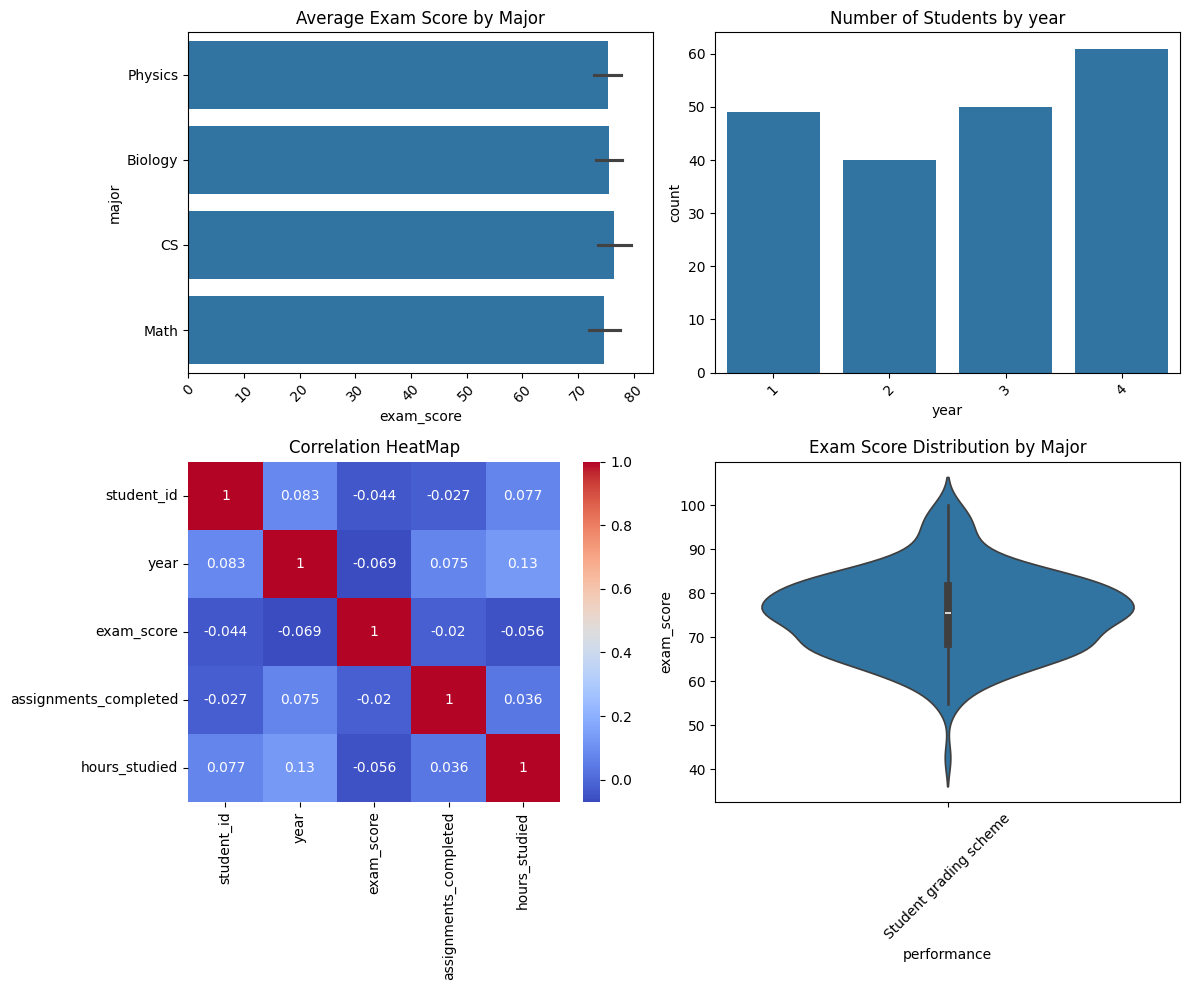

In [48]:
##Exercise 6

import matplotlib.pyplot as plt
import seaborn as sns

##Task 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

print(df.columns)

# Histogram
sns.histplot(
    data=df,
             x="exam_score",
             kde = True,
             ax = axes[0]
             )
axes[0].set_title("Distribution of Exam Scores")

# Second subplot
sns.boxplot(
    data = df,
    y = "exam_score",
ax = axes[1]
)
axes[1].set_title("Boxplot for Exam Scores")

plt.tight_layout()
plt.show()

##Task 2
plt.figure(figsize=(6,5))
plt.scatter(df["hours_studied"], df["exam_score"])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

x = df["hours_studied"]
y = df["exam_score"]

m, b = np.polyfit(x, y, 1)

x_sorted = np.sort(x)
y_sorted = m * x_sorted + b
plt.plot(x, m*x+b, color = "black", linewidth=2, label = "Regression line")

plt.title("Hours Studied vs Exam Score by Major")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()

plt.legend()
plt.show()

##Task 3
fig, axes = plt.subplots(2,2,figsize=(12, 10))
sns.barplot(data =df,
            x = "exam_score",
            y= "major",
            ax = axes[0, 0]
            )

axes[0,0].set_title("Average Exam Score by Major")
axes[0,0].tick_params(axis = 'x', rotation=45)

sns.countplot(data=df, x = "year", ax = axes[0, 1])

axes[0,1].set_title("Number of Students by year")
axes[0,1].tick_params(axis='x', rotation=45)

sns.heatmap(df.corr(numeric_only=True), annot =True, cmap = "coolwarm", ax = axes[1, 0])
axes[1, 0].set_title("Correlation HeatMap")

sns.violinplot(data=df, x = "performance", y = "exam_score", ax =axes[1,1])
axes[1,1].set_title("Exam Score Distribution by Major")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [52]:
##Exercise 7
np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame( {
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

df = customers
df["CLV"] = df["purchase_frequency"] * df["avg_purchase_value"]
churn_risk = 1 - (purchase_frequency / max_frequency)



df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

##calculating number of customers by age group
customer_count = df.groupby("Age_Group").size()
print(customer_count)

avg_income = df.groupby("Age_Group") ["income"].mean()
print(avg_income)

KeyError: 'purchase_frequency'